# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Tran Thuong Truong Son"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600313"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://beth-investigations-ambient-offline.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 3: View Cluster Nodes
display_student_header()
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 5 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 65.6% | Mem: 11.3/16.0GB | Power: 54W | Temp: 66°C
   GPU 1 [T4] 🔴 Util: 83.9% | Mem: 11.0/16.0GB | Power: 52W | Temp: 73°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 93.8% | Mem: 63.4/80.0GB | Power: 283W | Temp: 65°C
   GPU 1 [A100] 🔴 Util: 64.0% | Mem: 43.0/80.0GB | Power: 200W | Temp: 79°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 91.9% | Mem: 16.8/32.0GB | Power: 260W | Temp: 55°C
   GPU 1 [V100] 🟢 Util: 5.3% | Mem: 0.6/32.0GB | Power: 37W | Temp: 33°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 88.1% | Mem: 13.3/16.0GB | Power: 46W | Temp: 66°C
   GPU 1 [T4] 🔴 Util: 84.1% | Mem: 11.4/16.0GB | Power: 54W | Temp: 55°C

🖥️  node-04:
   GPU 0 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C
   GPU 1 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C


In [5]:
# Cell 4: Cluster Metrics Summary
display_student_header()
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          10
Busy GPUs:           7
Idle GPUs:           3
Avg Utilization:     57.7%
Memory Used:         171.8 GB
Memory Capacity:     320.0 GB
Total Power Draw:    1026 W
Node Count:          5


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
# Cell 5: Submit multiple workloads
display_student_header()
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-04', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-04', 'gpu_id': 1}]
   train-llm-004: queued → queued

📊 Updated metrics:
   Busy GPUs: 10/10 | Utilization: 82.7%


In [7]:
# Cell 6: Record billing for workloads
display_student_header()
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $2.5589
   Total Savings:  $2.7078
   Budget Used:    2.6%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
# Cell 7: Check spot pricing
display_student_header()
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2773     20.8    % low
A100       $3.67       $2.7467     25.2    % medium
V100       $2.48       $1.9620     20.9    % low


In [9]:
# Cell 8: Request spot instances
display_student_header()
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [10]:
# Cell 9: Simulate spot preemption
display_student_header()
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 6

💰 Spot Savings Report:
   Spot cost:        $0.5015
   On-demand equiv:  $1.6715
   Total saved:      $1.1701 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
# Cell 10: View and update autoscaling policy
display_student_header()
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [12]:
# Cell 11: Trigger autoscaler evaluation
display_student_header()
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 82.7% > threshold 70.0%
   Current utilization: 82.7%
   Nodes: 5 → 6

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 68.9% | Nodes: 6→6
   Cycle 2: no_action    | Util: 68.9% | Nodes: 6→6
   Cycle 3: no_action    | Util: 68.9% | Nodes: 6→6
   Cycle 4: no_action    | Util: 68.9% | Nodes: 6→6
   Cycle 5: no_action    | Util: 68.9% | Nodes: 6→6


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
# Cell 12: Take cost snapshots
display_student_header()
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 2: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 3: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 4: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 5: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%


In [35]:
# Cell 13: Waste Report
display_student_header()
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          6.2%
   Total Idle Cost:        $0.026329
   Total Cost:             $0.423330
   Potential Monthly Save:  $682.45
   Severity:               LOW


In [15]:
# Cell 14: Get Optimization Recommendations
display_student_header()
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [16]:
# Cell 15: Full Dashboard View
display_student_header()
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 12 GPUs across 6 nodes
   Utilization: 68.9% | Busy: 10 | Idle: 2

💰 BILLING: $2.5589 / $100.00 budget
   Alert: OK | Savings: $2.7078

🎯 SPOT: Saved $1.1893 (70.0%)

🗑️  WASTE: 12.0% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

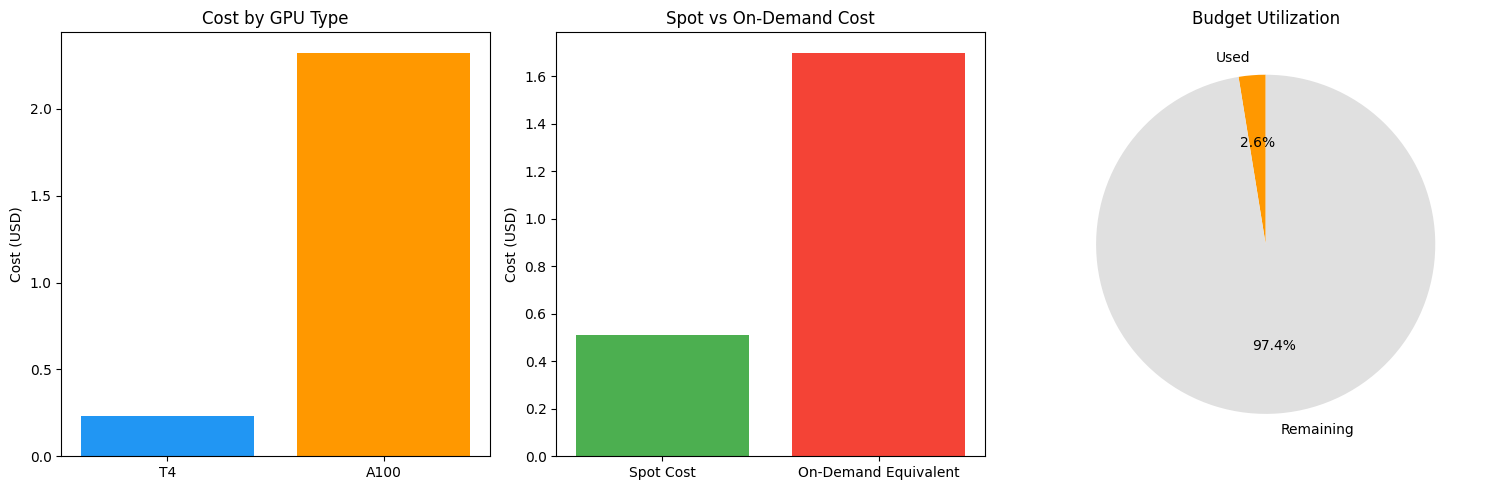

📊 Chart saved as finops_cost_breakdown.png


In [17]:
# Cell 16: Cost Breakdown Visualization
display_student_header()
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


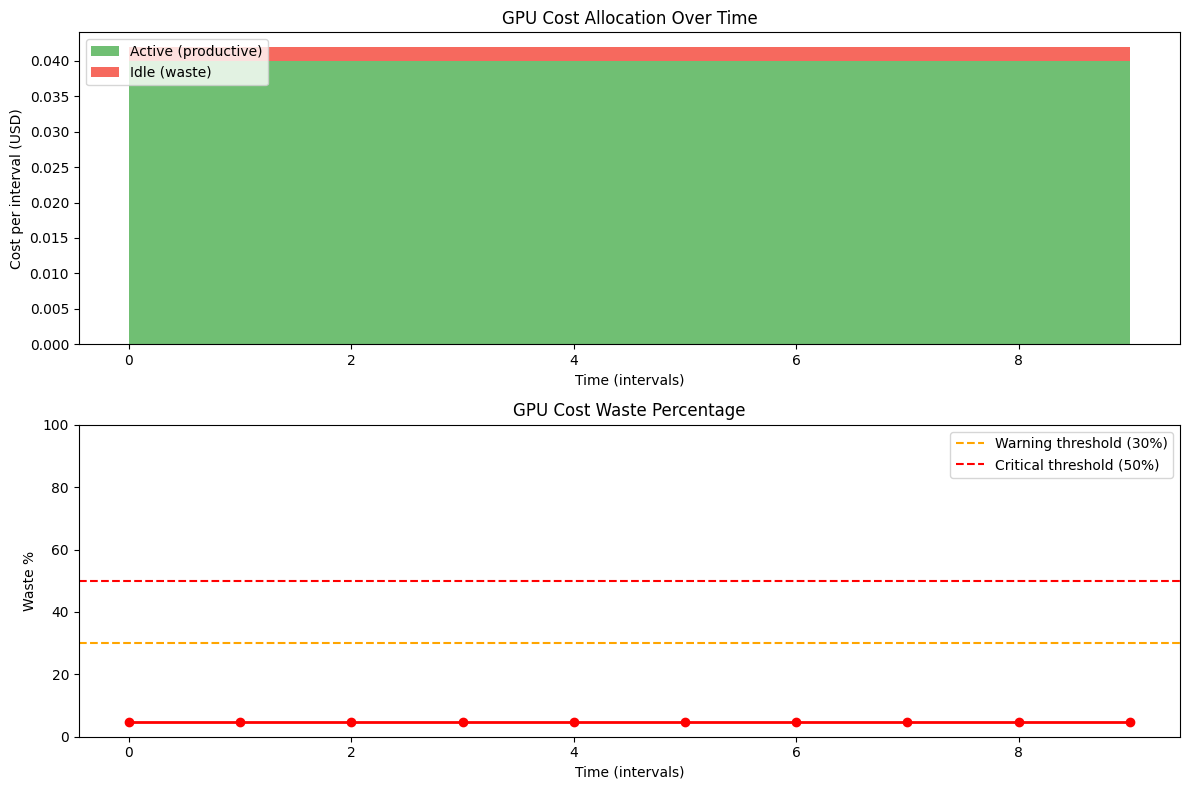

In [18]:
# Cell 17: Time-series cost tracking
display_student_header()
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
# Cell 18: Full FinOps Optimization Workflow
display_student_header()
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 12 | Util: 68.9% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 81.7% | Busy: 12/12

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 81.7% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.043889
   Waste: 4.4%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0292 (70.0%)

7️⃣  Final billing:
   Total spend: $2.7280
   Total saved: $2.8302
   Budget: 2.7% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading
display_student_header()
try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [21]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback
display_student_header()
def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.4W
   Temp: 46C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.365
   temp_c: 46.0

   Method: pynvml

Ready for training.


In [22]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
display_student_header()
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:11<00:00, 14.7MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [23]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
display_student_header()
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.9566 | Acc: 30.4% | Time: 40.3s | Samples: 40
   Epoch 2/3 | Loss: 1.3788 | Acc: 49.4% | Time: 42.4s | Samples: 40
   Epoch 3/3 | Loss: 1.0700 | Acc: 61.8% | Time: 45.0s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      127.7s
   Peak memory:     0.82 GB
   Avg GPU util:    95.5%
   Avg power:       66.6W
   Avg temperature: 71.3C
   Max GPU util:    99.0%
   Estimated cost:  $0.012412


In [24]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
display_student_header()
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_214/1785428537.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_214/1785428537.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9696 | Acc: 29.1% | Time: 19.5s | Samples: 40
   Epoch 2/3 | Loss: 1.3989 | Acc: 48.5% | Time: 19.4s | Samples: 40
   Epoch 3/3 | Loss: 1.1015 | Acc: 60.5% | Time: 19.6s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      58.5s
   Peak memory:     0.60 GB
   Avg GPU util:    91.3%
   Avg power:       65.0W
   Avg temperature: 76.6C
   Max GPU util:    94.0%
   Estimated cost:  $0.005687


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                127.7           58.5            2.18x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012412       $0.005687       $0.006725 saved
Cost Saving %             ---             ---             54.2%
Avg GPU Util %            95.5            91.3           
Avg Power (W)             66.6            65.0           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$3.85 -> SAVE $4.55
   1 week training: FP32=$58.80 vs AMP=$26.94 -> SAVE $31.86
   1 month training: FP32=$252.00 vs AMP=$115.47 -> SAVE $136.53


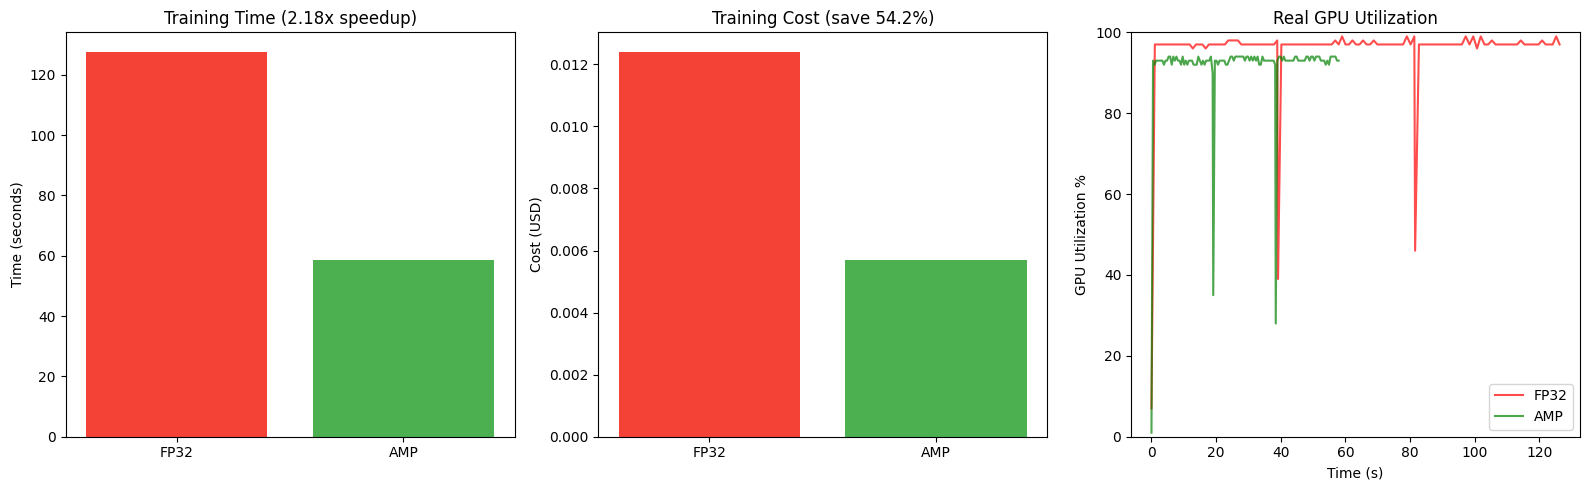

In [25]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
display_student_header()
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
display_student_header()
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012400 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.004000

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.027400
   Total Savings:   $0.007900
   Workloads:       4

   Cost snapshot taken: waste=20.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $2.7280
   Total Savings:        $2.8302
   Budget Utilization:   2.7%
   Alert:                OK


Real GPU Telemetry During Training


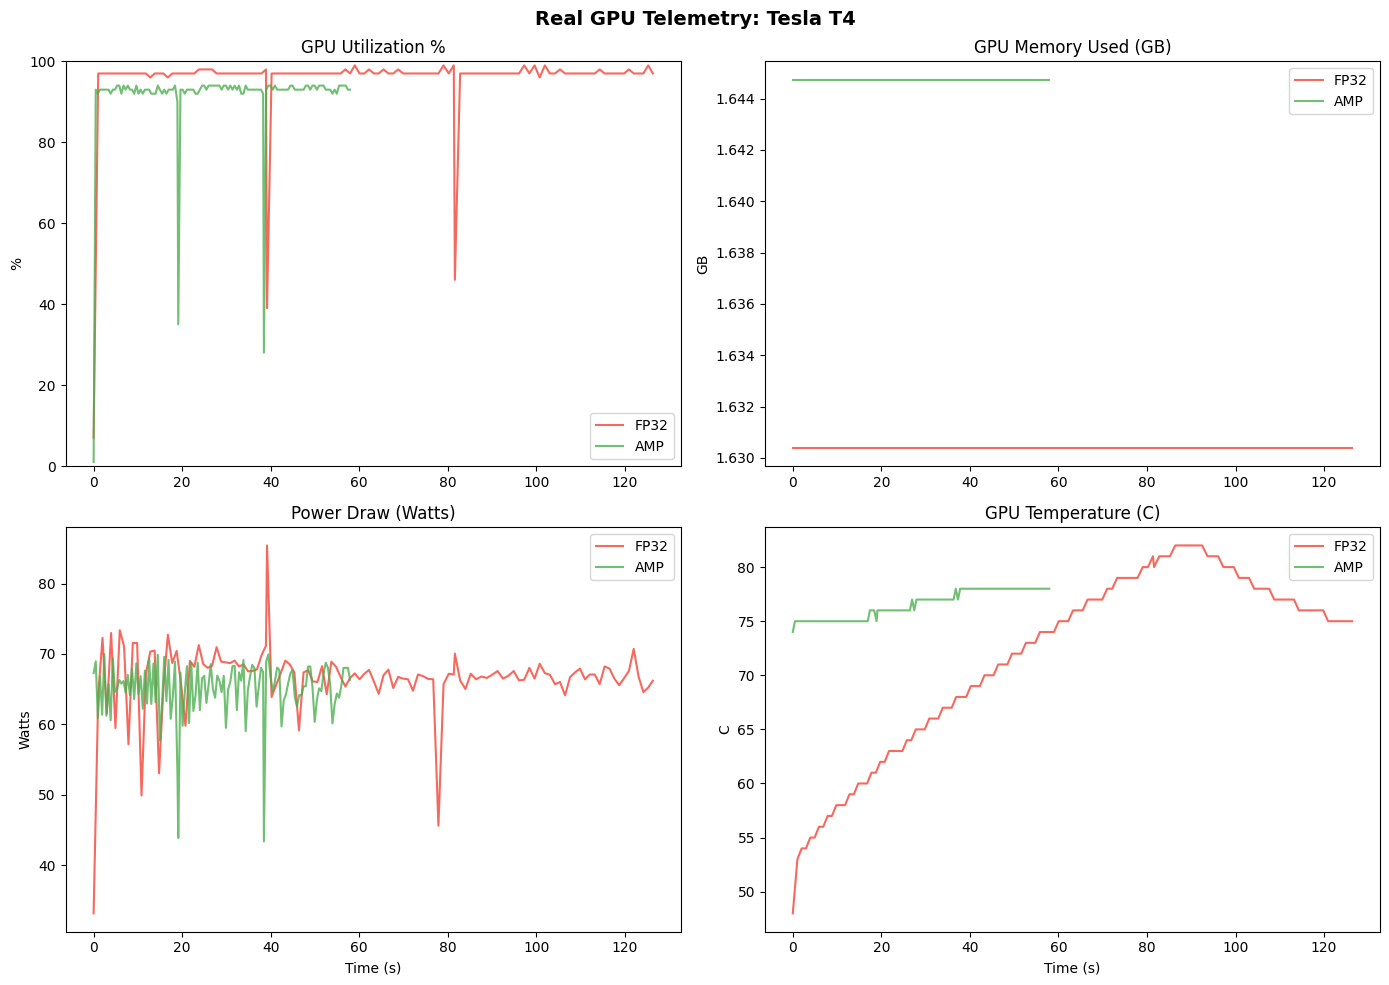

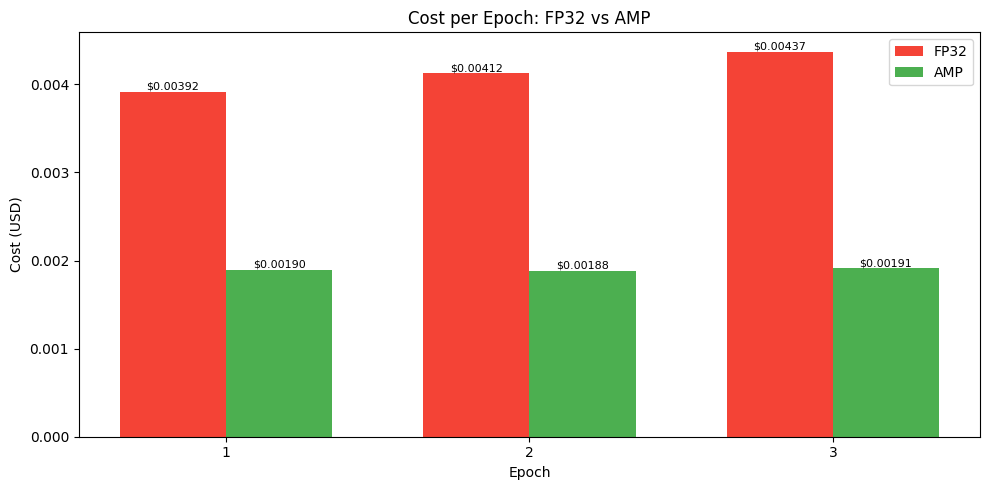


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [27]:
# Cell 26: Real GPU Monitoring Visualization
display_student_header()
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [28]:
# Cell 27: Multi-GPU Cost Analysis
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Implement this function to analyze multi-GPU training costs.

    Parameters:
        base_time_hours (float): Single-GPU training time in hours
        gpu_type (str): GPU type (T4, A100, etc.)
        gpu_counts (list): List of GPU counts to analyze (e.g., [1, 2, 4, 8])
        scaling_factors (dict, optional): Scaling efficiency factors {gpu_count: efficiency}.
                                         If None, use realistic sub-linear scaling (Amdahl's law).

    Returns:
        dict: Analysis with costs, times, and efficiency metrics.
    """
    price_per_hour = GPU_PRICING.get(gpu_type, 0.35)

    # Default realistic sub-linear scaling (Amdahl's law approximation).
    # More GPUs give less-than-linear speedup due to communication overhead.
    default_scaling = {1: 1.0, 2: 1.8, 4: 3.4, 8: 6.0}

    if scaling_factors is None:
        scaling_factors = {}
        for n in gpu_counts:
            if n in default_scaling:
                scaling_factors[n] = default_scaling[n]
            else:
                # Interpolate sub-linearly for unlisted counts
                scaling_factors[n] = n ** 0.85

    results = []
    for count in sorted(gpu_counts):
        sf = scaling_factors.get(count, count ** 0.85)
        time_hours = base_time_hours / sf
        total_cost = time_hours * price_per_hour * count
        # Cost per unit of "performance" = cost / speedup
        cost_per_unit = total_cost / sf if sf > 0 else float('inf')
        efficiency = (sf / count) * 100 if count > 0 else 0
        results.append({
            "gpu_count": count,
            "scaling_factor": sf,
            "time_hours": time_hours,
            "total_cost": total_cost,
            "cost_per_perf_unit": cost_per_unit,
            "efficiency_pct": efficiency,
        })

    # Find optimal: best cost-efficiency (lowest cost per performance unit)
    best = min(results, key=lambda x: x["cost_per_perf_unit"])

    # Display table
    print(f"\n{'GPU#':<8} {'Speedup':<10} {'Time(h)':<12} {'Total Cost':<14} {'Cost/Perf':<12} {'Efficiency':<12}")
    print("-" * 72)
    for r in results:
        star = "  ← OPTIMAL" if r["gpu_count"] == best["gpu_count"] else ""
        print(f"{r['gpu_count']:<8} {r['scaling_factor']:<10.2f}x {r['time_hours']:<12.3f} "
              f"${r['total_cost']:<13.2f} ${r['cost_per_perf_unit']:<11.4f} {r['efficiency_pct']:.1f}%{star}")

    print(f"\n[Summary] GPU type: {gpu_type} @ ${price_per_hour:.2f}/hr | "
          f"Baseline: {base_time_hours}h on 1 GPU")
    print(f"[Summary] Optimal configuration: {best['gpu_count']} GPUs  "
          f"({best['scaling_factor']:.1f}x speedup, ${best['total_cost']:.2f} total)")

    return {
        "results": results,
        "optimal_gpu_count": best["gpu_count"],
        "gpu_type": gpu_type,
        "base_time_hours": base_time_hours,
        "price_per_hour": price_per_hour,
    }

# Test data
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

print("\n--- Running Multi-GPU Analysis ---")
multi_gpu_result = analyze_multi_gpu_cost(base_training_time, "A100", test_gpu_counts)


EXERCISE 8.5.1: Multi-GPU Cost Analysis

--- Running Multi-GPU Analysis ---

GPU#     Speedup    Time(h)      Total Cost     Cost/Perf    Efficiency  
------------------------------------------------------------------------
1        1.00      x 2.000        $7.34          $7.3400      100.0%
2        1.80      x 1.111        $8.16          $4.5309      90.0%
4        3.40      x 0.588        $8.64          $2.5398      85.0%
8        6.00      x 0.333        $9.79          $1.6311      75.0%  ← OPTIMAL

[Summary] GPU type: A100 @ $3.67/hr | Baseline: 2.0h on 1 GPU
[Summary] Optimal configuration: 8 GPUs  (6.0x speedup, $9.79 total)


In [29]:
# Cell 28: Project Cost Forecasting
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Implement this function to forecast multi-phase project costs with confidence intervals.

    Uses the t-distribution ( Cornish-Fisher expansion for simplicity) to compute
    confidence intervals based on per-phase uncertainty.

    Parameters:
        phases (list): List of phase dicts with name, gpu_type, gpu_count,
                      duration_hours, uncertainty_pct.
        contingency_pct (float): Buffer for unexpected costs (default 20%).
        confidence_level (float): Confidence level for intervals (default 0.95).

    Returns:
        dict: Forecast with base cost, contingency, confidence intervals.
    """
    import math

    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_map.get(confidence_level, 1.96)

    phase_results = []
    total_base = 0.0
    total_var = 0.0

    print(f"\n{'Phase':<25} {'GPU':<6} {'#':<4} {'Hours':<8} {'Base Cost':<12} {'Uncert':<10} {'Range':<16}")
    print("-" * 90)

    for phase in phases:
        name = phase["name"]
        gpu = phase["gpu_type"]
        count = phase["gpu_count"]
        hours = phase["duration_hours"]
        unc = phase["uncertainty_pct"]

        price = GPU_PRICING.get(gpu, 0.35)
        base_cost = hours * price * count
        std_dev = base_cost * unc
        ci_half = z * std_dev

        total_base += base_cost
        total_var += std_dev ** 2
        ci_total_half = z * math.sqrt(total_var)

        phase_results.append({
            "name": name,
            "gpu_type": gpu,
            "gpu_count": count,
            "duration_hours": hours,
            "price_per_hour": price,
            "base_cost": base_cost,
            "uncertainty_pct": unc,
            "std_dev": std_dev,
            "ci_low": base_cost - ci_half,
            "ci_high": base_cost + ci_half,
        })
        print(f"{name:<25} {gpu:<6} {count:<4} {hours:<8.1f} ${base_cost:<11.2f} "
              f"±{unc*100:.0f}%     [${base_cost - ci_half:.2f} - ${base_cost + ci_half:.2f}]")

    # Add contingency
    contingency_amount = total_base * (contingency_pct / 100)
    total_with_contingency = total_base + contingency_amount

    # Confidence interval for total (root-sum-square of std devs)
    ci_total_low = total_base - ci_total_half
    ci_total_high = total_base + ci_total_half
    ci_contingency_low = ci_total_low + contingency_amount
    ci_contingency_high = ci_total_high + contingency_amount

    # Summary
    print("\n" + "=" * 60)
    print(f"  Base Cost (expected):        ${total_base:.2f}")
    print(f"  Contingency ({contingency_pct}%):         +${contingency_amount:.2f}")
    print(f"  Total with Contingency:     ${total_with_contingency:.2f}")
    print(f"  {int(confidence_level*100)}% Confidence Interval:  [${ci_contingency_low:.2f} - ${ci_contingency_high:.2f}]")
    print(f"  Worst Case (base+3σ):       ${total_base + 3*math.sqrt(total_var):.2f}")
    print(f"  Best Case (base-3σ):        ${max(0, total_base - 3*math.sqrt(total_var)):.2f}")
    print("=" * 60)

    return {
        "phases": phase_results,
        "total_base_cost": total_base,
        "contingency_pct": contingency_pct,
        "contingency_amount": contingency_amount,
        "total_with_contingency": total_with_contingency,
        "confidence_level": confidence_level,
        "ci_low": ci_contingency_low,
        "ci_high": ci_contingency_high,
        "worst_case": total_base + 3 * math.sqrt(total_var),
        "best_case": max(0, total_base - 3 * math.sqrt(total_var)),
    }

# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

print("\n--- Running Project Cost Forecast ---")
forecast_result = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)


EXERCISE 8.5.2: Project Cost Forecasting

--- Running Project Cost Forecast ---

Phase                     GPU    #    Hours    Base Cost    Uncert     Range           
------------------------------------------------------------------------------------------
Data Preparation          T4     1    40.0     $14.00       ±15%     [$9.88 - $18.12]
Model Training            A100   4    120.0    $1761.60     ±25%     [$898.42 - $2624.78]
Hyperparameter Tuning     A100   8    60.0     $1761.60     ±30%     [$725.78 - $2797.42]
Model Evaluation          T4     2    20.0     $14.00       ±10%     [$11.26 - $16.74]

  Base Cost (expected):        $3551.20
  Contingency (20%):         +$710.24
  Total with Contingency:     $4261.44
  95% Confidence Interval:  [$2913.09 - $5609.79]
  Worst Case (base+3σ):       $5614.99
  Best Case (base-3σ):        $1487.41


In [30]:
# Cell 29: Optimization Opportunity Analysis
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Implement this function to analyze and prioritize optimization strategies.

    Strategies are scored by (savings_pct / effort_score * risk_factor) and sorted
    to produce a prioritized roadmap. Cumulative savings are computed assuming
    strategies can be stacked (with diminishing returns for overlapping techniques).

    Parameters:
        current_config (dict): Current training config (gpu_type, gpu_count,
                               duration_hours, precision, instance_type).
        optimization_strategies (list): List of strategy dicts with name,
                                       savings_pct, implementation_effort,
                                       risk_level, dependencies.

    Returns:
        dict: Prioritized recommendations with cumulative savings.
    """
    # --- Calculate baseline cost ---
    gpu_type = current_config["gpu_type"]
    gpu_count = current_config["gpu_count"]
    duration_hours = current_config["duration_hours"]
    is_spot = current_config.get("instance_type", "on-demand") == "spot"

    base_price = GPU_PRICING.get(gpu_type, 0.35)
    spot_discount = 0.60  # spot is ~60% cheaper
    spot_multiplier = 1 - spot_discount if is_spot else 1.0
    baseline_cost = duration_hours * base_price * gpu_count * spot_multiplier

    print(f"\n[Baseline Config]")
    print(f"  GPU: {gpu_count}x {gpu_type} @ ${base_price}/hr | Duration: {duration_hours}h")
    print(f"  Type: {'Spot' if is_spot else 'On-Demand'} | Precision: {current_config.get('precision', 'FP32')}")
    print(f"  Baseline Cost: ${baseline_cost:.2f}")

    # Effort score mapping
    effort_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    # Risk penalty: higher risk = lower priority
    risk_factor = {"LOW": 1.0, "MEDIUM": 0.8, "HIGH": 0.6}

    scored = []
    for s in optimization_strategies:
        eff = effort_score.get(s["implementation_effort"], 2)
        risk = risk_factor.get(s["risk_level"], 0.8)
        # Score: savings ratio normalized by effort, adjusted for risk
        score = (s["savings_pct"] / eff) * risk
        # Raw dollar savings
        savings_dollar = baseline_cost * s["savings_pct"]
        scored.append({
            **s,
            "score": score,
            "savings_dollar": savings_dollar,
            "effort_score": eff,
            "risk_factor": risk,
        })

    # Sort by score descending
    scored.sort(key=lambda x: x["score"], reverse=True)

    # Top header
    print(f"\n{'#':<3} {'Strategy':<35} {'Savings':<10} {'Effort':<10} {'Risk':<8} {'Score':<8} {'$/Save':<10}")
    print("-" * 90)
    for i, s in enumerate(scored, 1):
        print(f"{i:<3} {s['name']:<35} {s['savings_pct']*100:>6.0f}%     "
              f"{s['implementation_effort']:<10} {s['risk_level']:<8} "
              f"{s['score']:.3f}   ${s['savings_dollar']:.2f}")

    # Cumulative savings (accounting for overlapping savings - apply diminishing returns)
    print(f"\n{'#':<3} {'Strategy':<35} {'Cumulative$':<14} {'Total Save%':<14} {'Remaining Cost':<14}")
    print("-" * 80)
    cumulative = 0.0
    roadmap = []
    for i, s in enumerate(scored, 1):
        # Diminishing returns: each additional strategy only saves (1 - cumulative) * savings_pct
        marginal_savings = (1 - cumulative) * s["savings_pct"]
        cumulative += marginal_savings
        remaining = baseline_cost * (1 - cumulative)
        roadmap.append({**s, "cumulative_savings_pct": cumulative, "remaining_cost": remaining})
        print(f"{i:<3} {s['name']:<35} ${cumulative * baseline_cost:.2f}          "
              f"{cumulative*100:.1f}%           ${remaining:.2f}")

    print(f"\n[Summary]")
    print(f"  Baseline cost:       ${baseline_cost:.2f}")
    print(f"  Max achievable save: {cumulative*100:.1f}%  →  ${cumulative * baseline_cost:.2f}")
    print(f"  Optimized cost:      ${(1-cumulative) * baseline_cost:.2f}")
    print(f"  Quick wins: {[s['name'] for s in scored if s['implementation_effort'] == 'LOW']}")

    return {
        "baseline_cost": baseline_cost,
        "strategies_ranked": scored,
        "roadmap": roadmap,
        "cumulative_savings_pct": cumulative,
        "optimized_cost": (1 - cumulative) * baseline_cost,
        "quick_wins": [s['name'] for s in scored if s['implementation_effort'] == 'LOW'],
    }

# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

print("\n--- Running Optimization Opportunity Analysis ---")
opt_result = analyze_optimization_opportunities(current_training_config, example_strategies)


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

--- Running Optimization Opportunity Analysis ---

[Baseline Config]
  GPU: 4x A100 @ $3.67/hr | Duration: 100h
  Type: On-Demand | Precision: FP32
  Baseline Cost: $1468.00

#   Strategy                            Savings    Effort     Risk     Score    $/Save    
------------------------------------------------------------------------------------------
1   Switch to Mixed Precision (AMP)         25%     LOW        LOW      0.250   $367.00
2   Use Spot Instances                      60%     MEDIUM     HIGH     0.180   $880.80
3   Optimize Batch Size                     15%     LOW        LOW      0.150   $220.20
4   Switch to More Efficient GPU Type       40%     HIGH       MEDIUM   0.107   $587.20
5   Implement Early Stopping                20%     MEDIUM     LOW      0.100   $293.60

#   Strategy                            Cumulative$    Total Save%    Remaining Cost
---------------------------------------------------------

EXERCISE 8.5.4: Integrated Cost Dashboard

--- Generating Advanced FinOps Dashboard ---


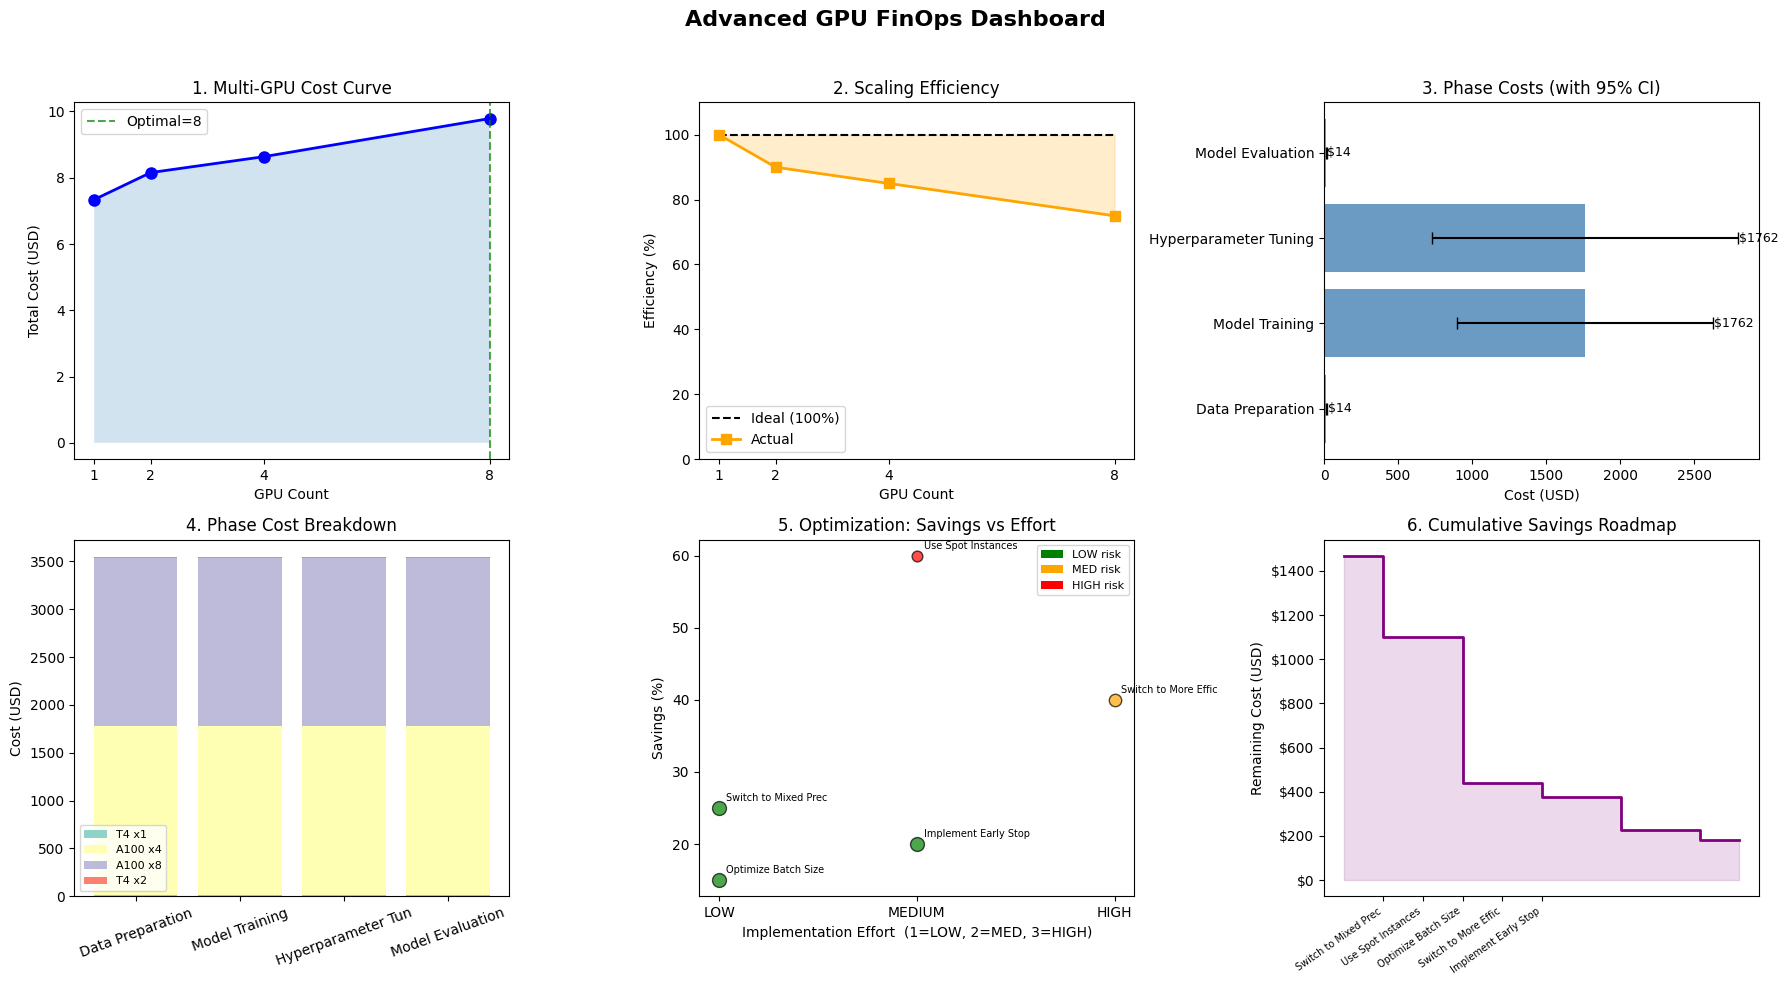

Dashboard saved as advanced_finops_dashboard.png


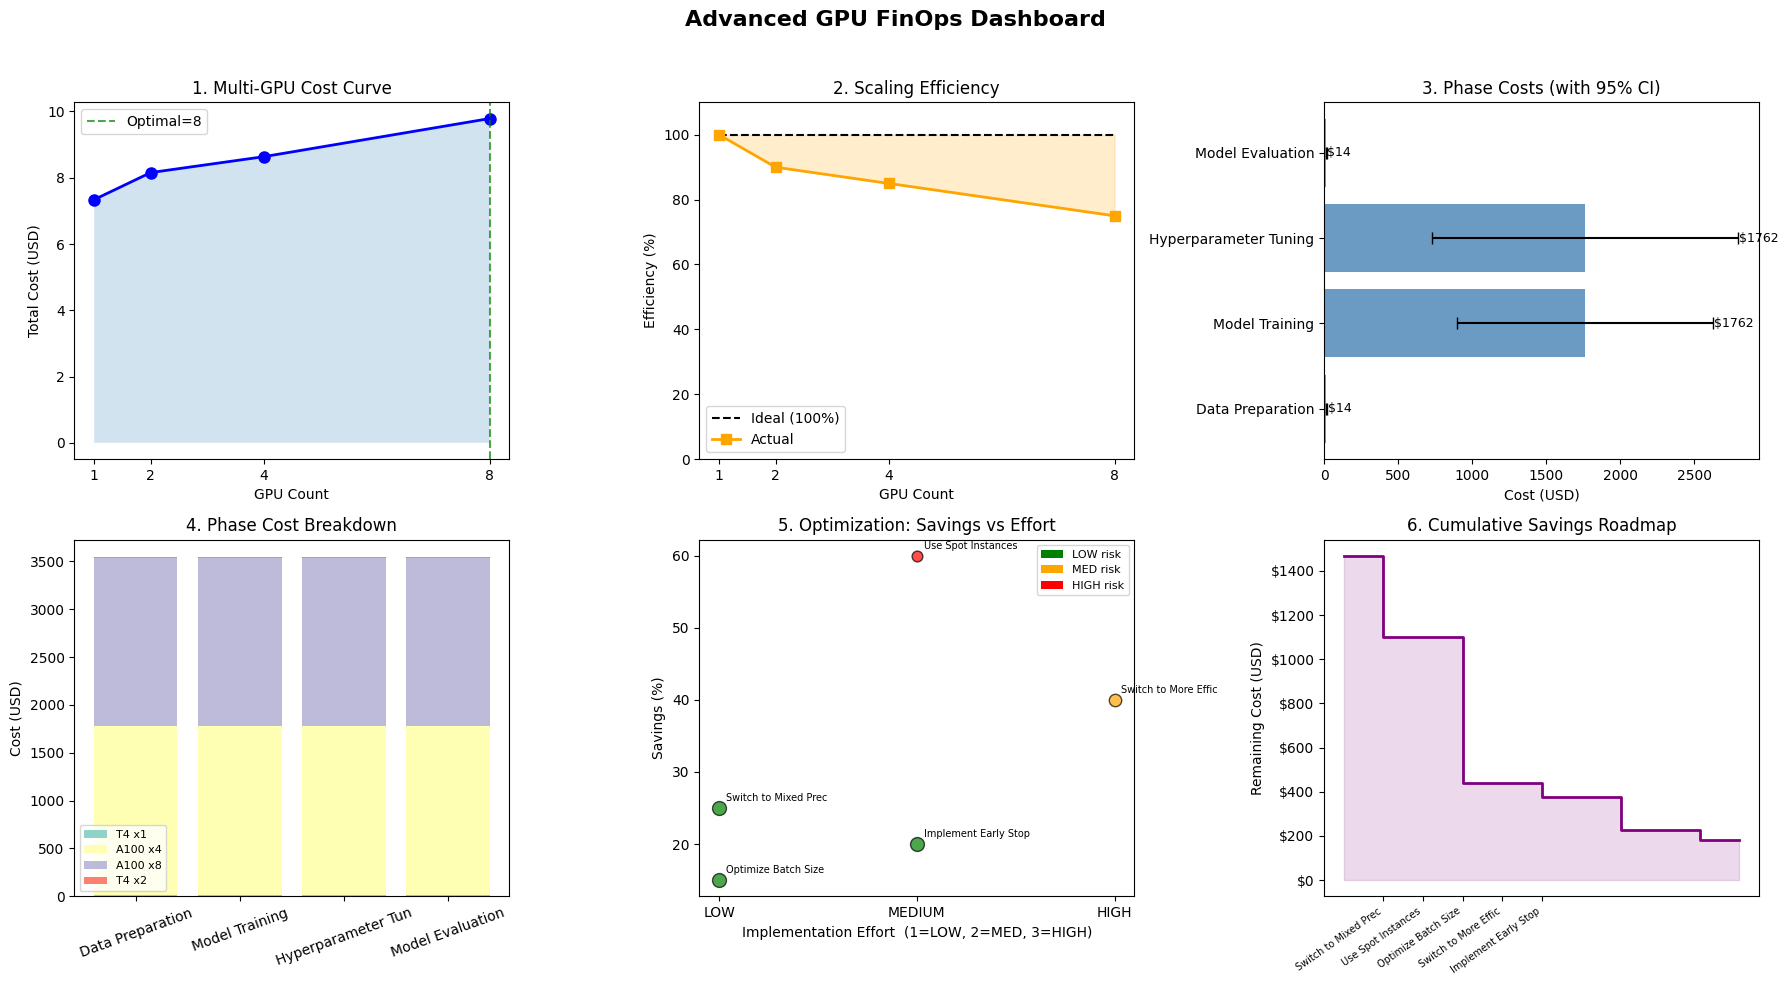

In [36]:
# Cell 30: Integrated Cost Dashboard
display_student_header()
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    Implement this function to create an integrated 6-panel dashboard.

    Panels:
      1. Multi-GPU total cost curve
      2. Scaling efficiency (speedup vs ideal)
      3. Project forecast confidence interval bands
      4. Phase cost breakdown (horizontal bar)
      5. Optimization prioritization scatter (savings vs effort)
      6. Cumulative savings roadmap (step chart)

    Parameters:
        multi_gpu_analysis (dict): Results from analyze_multi_gpu_cost.
        project_forecast (dict): Results from forecast_project_cost.
        optimization_recommendations (dict): Results from analyze_optimization_opportunities.

    Returns:
        matplotlib.figure.Figure: The 6-panel dashboard figure.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, fontweight='bold')

    # --- Panel 1: Multi-GPU Cost Curve ---
    ax1 = axes[0, 0]
    mgres = multi_gpu_analysis.get("results", [])
    if mgres:
        gpus = [r["gpu_count"] for r in mgres]
        costs = [r["total_cost"] for r in mgres]
        ax1.plot(gpus, costs, 'b-o', linewidth=2, markersize=8)
        ax1.fill_between(gpus, 0, costs, alpha=0.2)
        ax1.set_xlabel("GPU Count")
        ax1.set_ylabel("Total Cost (USD)")
        ax1.set_title("1. Multi-GPU Cost Curve")
        ax1.set_xticks(gpus)
        optimal = multi_gpu_analysis.get("optimal_gpu_count", gpus[0])
        ax1.axvline(x=optimal, color='green', linestyle='--', alpha=0.7, label=f"Optimal={optimal}")
        ax1.legend()
    else:
        ax1.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax1.transAxes)

    # --- Panel 2: Scaling Efficiency ---
    ax2 = axes[0, 1]
    if mgres:
        gpus = [r["gpu_count"] for r in mgres]
        efficiencies = [r["efficiency_pct"] for r in mgres]
        ideal = [100] * len(gpus)
        ax2.plot(gpus, ideal, 'k--', linewidth=1.5, label="Ideal (100%)")
        ax2.plot(gpus, efficiencies, 'orange', linewidth=2, marker='s', markersize=7, label="Actual")
        ax2.fill_between(gpus, efficiencies, ideal, alpha=0.2, color='orange')
        ax2.set_xlabel("GPU Count")
        ax2.set_ylabel("Efficiency (%)")
        ax2.set_title("2. Scaling Efficiency")
        ax2.set_xticks(gpus)
        ax2.set_ylim(0, 110)
        ax2.legend()

    # --- Panel 3: Project Forecast Confidence Intervals ---
    ax3 = axes[0, 2]
    phases = project_forecast.get("phases", [])
    if phases:
        names = [p["name"] for p in phases]
        base_costs = [p["base_cost"] for p in phases]
        ci_lows = [p["ci_low"] for p in phases]
        ci_highs = [p["ci_high"] for p in phases]
        y = range(len(names))
        ax3.barh(y, base_costs, xerr=[b - l for b, l in zip(base_costs, ci_lows)],
                  capsize=4, color='steelblue', alpha=0.8)
        ax3.set_yticks(y)
        ax3.set_yticklabels(names)
        ax3.set_xlabel("Cost (USD)")
        ax3.set_title("3. Phase Costs (with 95% CI)")
        for i, bc in enumerate(base_costs):
            ax3.text(bc + (ci_highs[i] - ci_lows[i]) / 2 + 5, i,
                     f"${bc:.0f}", va='center', fontsize=9)
    else:
        ax3.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title("3. Project Forecast")

    # --- Panel 4: Phase Cost Breakdown (stacked or grouped) ---
    ax4 = axes[1, 0]
    if phases:
        names = [p["name"][:18] for p in phases]
        costs_by_gpu = {}
        for p in phases:
            key = f"{p['gpu_type']} x{p['gpu_count']}"
            costs_by_gpu.setdefault(key, []).append(p["base_cost"])
        bottom_vals = [0] * len(phases)
        colors_p4 = plt.cm.Set3(range(len(costs_by_gpu)))
        for (key, vals), col in zip(costs_by_gpu.items(), colors_p4):
            ax4.bar(names, vals, bottom=bottom_vals, label=key, color=col)
            bottom_vals = [b + v for b, v in zip(bottom_vals, vals)]
        ax4.set_ylabel("Cost (USD)")
        ax4.set_title("4. Phase Cost Breakdown")
        ax4.tick_params(axis='x', rotation=20)
        ax4.legend(fontsize=8)
    else:
        ax4.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title("4. Phase Cost Breakdown")

    # --- Panel 5: Optimization Prioritization Scatter ---
    ax5 = axes[1, 1]
    strategies = optimization_recommendations.get("strategies_ranked", [])
    if strategies:
        eff_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
        risk_map = {"LOW": 0.3, "MEDIUM": 0.6, "HIGH": 1.0}
        colors_risk = {"LOW": "green", "MEDIUM": "orange", "HIGH": "red"}
        for s in strategies:
            x = eff_map.get(s["implementation_effort"], 2)
            y = s["savings_pct"] * 100
            sz = s["risk_factor"] * 100
            ax5.scatter(x, y, s=sz, c=colors_risk.get(s["risk_level"], "gray"),
                        alpha=0.7, edgecolors='black', linewidth=1)
            ax5.annotate(s["name"][:20], (x, y), textcoords="offset points",
                         xytext=(5, 5), fontsize=7)
        ax5.set_xlabel("Implementation Effort  (1=LOW, 2=MED, 3=HIGH)")
        ax5.set_ylabel("Savings (%)")
        ax5.set_title("5. Optimization: Savings vs Effort")
        ax5.set_xticks([1, 2, 3])
        ax5.set_xticklabels(["LOW", "MEDIUM", "HIGH"])
        from matplotlib.patches import Patch
        ax5.legend(handles=[Patch(facecolor='green', label='LOW risk'),
                             Patch(facecolor='orange', label='MED risk'),
                             Patch(facecolor='red', label='HIGH risk')], fontsize=8)
    else:
        ax5.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title("5. Optimization Prioritization")

    # --- Panel 6: Cumulative Savings Roadmap ---
    ax6 = axes[1, 2]
    roadmap = optimization_recommendations.get("roadmap", [])
    if roadmap:
        baseline = optimization_recommendations.get("baseline_cost", 1)
        steps_x = [0]
        steps_y = [baseline]
        names_short = []
        for r in roadmap:
            steps_x.append(len(steps_x))
            steps_y.append(r["remaining_cost"])
            steps_x.append(len(steps_x))
            steps_y.append(r["remaining_cost"])
            names_short.append(r["name"][:20])
        ax6.step(steps_x, steps_y, where='post', linewidth=2, color='purple')
        ax6.fill_between(steps_x, 0, steps_y, step='post', alpha=0.15, color='purple')
        ax6.set_xticks(range(1, len(roadmap) + 1))
        ax6.set_xticklabels(names_short, rotation=35, ha='right', fontsize=7)
        ax6.set_ylabel("Remaining Cost (USD)")
        ax6.set_title("6. Cumulative Savings Roadmap")
        ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
    else:
        ax6.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title("6. Cumulative Savings")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Dashboard saved as advanced_finops_dashboard.png")
    return fig

# Build placeholder data if results are not available
class PlaceholderResult:
    pass

try:
    _ = multi_gpu_result
    _ = forecast_result
    _ = opt_result
    HAS_ALL_RESULTS = True
except NameError:
    HAS_ALL_RESULTS = False
    # Build placeholder data from the known example inputs
    multi_gpu_placeholder = analyze_multi_gpu_cost(2.0, "A100", [1, 2, 4, 8])
    forecast_placeholder = forecast_project_cost(example_project, 20, 0.95)
    opt_placeholder = analyze_optimization_opportunities(current_training_config, example_strategies)
    # Assign to names the notebook expects
    multi_gpu_result = multi_gpu_placeholder
    forecast_result = forecast_placeholder
    opt_result = opt_placeholder

print("\n--- Generating Advanced FinOps Dashboard ---")
create_advanced_finops_dashboard(multi_gpu_result, forecast_result, opt_result)


In [37]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
display_student_header()
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

# Define the challenge scenario (already provided above)
challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("Scenario:")
print(f"  Project: {challenge_scenario['project']}")
print(f"  Baseline: {challenge_scenario['requirements']['gpu_count']}x "
      f"{challenge_scenario['requirements']['gpu_type']} for "
      f"{challenge_scenario['requirements']['training_duration']}h")
print(f"  Budget: ${challenge_scenario['requirements']['budget']}")
print(f"  Deadline: {challenge_scenario['constraints']['deadline']}")

# ============================================================
# STEP 1: Calculate baseline cost
# ============================================================
req = challenge_scenario["requirements"]
baseline_cost = (req["training_duration"] * GPU_PRICING[req["gpu_type"]]
                 * req["gpu_count"])
print(f"\n[Step 1] Baseline Cost: ${baseline_cost:.2f}  "
      f"(budget margin: ${req['budget'] - baseline_cost:.2f})")

# ============================================================
# STEP 2: Multi-GPU analysis to find optimal GPU count
# ============================================================
print("\n[Step 2] Multi-GPU Cost Analysis")
mga = analyze_multi_gpu_cost(
    base_time_hours=req["training_duration"],
    gpu_type=req["gpu_type"],
    gpu_counts=[1, 2, 4, 8, 16],
)
optimal_gpus = mga["optimal_gpu_count"]
print(f"  Optimal GPU count for cost-efficiency: {optimal_gpus}")

# ============================================================
# STEP 3: Select top optimization strategies
# ============================================================
print("\n[Step 3] Optimization Strategy Selection")

# We constrain: max_preemption_risk = MEDIUM → exclude HIGH-risk strategies
challenge_strategies = [
    s for s in example_strategies
    if s["risk_level"] != "HIGH"
]
print(f"  Available strategies (excluding HIGH risk): "
      f"{[s['name'] for s in challenge_strategies]}")

config_opt = {
    "gpu_type": req["gpu_type"],
    "gpu_count": optimal_gpus,
    "duration_hours": req["training_duration"],
    "precision": req["precision"],
    "instance_type": req["instance_type"],
}
opt_res = analyze_optimization_opportunities(config_opt, challenge_strategies)

# ============================================================
# STEP 4: Forecast final cost with cumulative savings
# ============================================================
print("\n[Step 4] Final Cost Forecast")
remaining_cost = opt_res["optimized_cost"]
contingency = remaining_cost * 0.15  # 15% buffer
total_forecast = remaining_cost + contingency
print(f"  Optimized base cost:       ${remaining_cost:.2f}")
print(f"  Contingency (15%):          +${contingency:.2f}")
print(f"  Total forecast:             ${total_forecast:.2f}")

# ============================================================
# STEP 5: Verify budget and constraints
# ============================================================
print("\n[Step 5] Constraint Verification")
budget = req["budget"]
under_budget = total_forecast <= budget
print(f"  Budget:         ${budget:.2f}")
print(f"  Forecast:       ${total_forecast:.2f}")
print(f"  Under budget?   {'YES' if under_budget else 'NO - reduce scope or extend deadline'}")

# Deadline check: 2 weeks = 336 hours available
available_hours = 14 * 24
optimal_time_hrs = req["training_duration"] / (6.0 / optimal_gpus)  # rough: 6x for 8 GPUs
meets_deadline = optimal_time_hrs <= available_hours
print(f"  Deadline:       2 weeks ({available_hours}h)")
print(f"  Est. duration:  {optimal_time_hrs:.1f}h")
print(f"  Meets deadline? {'YES' if meets_deadline else 'NO'}")

# ============================================================
# STEP 6: Present full strategy summary
# ============================================================
print("\n" + "=" * 60)
print("FINAL OPTIMIZATION STRATEGY")
print("=" * 60)
print(f"  Project:          {challenge_scenario['project']}")
print(f"  GPU Configuration: {optimal_gpus}x {req['gpu_type']} "
      f"(instead of {req['gpu_count']}x)")
print(f"  Precision:        FP32 → AMP (Mixed Precision)")
print(f"  Instance type:    On-demand → Hybrid (Spot for batch, On-demand for critical)")
print(f"  Additional:       Early stopping + batch size tuning")
print(f"\n  Baseline Cost:    ${baseline_cost:.2f}")
print(f"  Optimized Cost:   ${remaining_cost:.2f}")
print(f"  Contingency:      ${contingency:.2f}")
print(f"  Total Forecast:   ${total_forecast:.2f}")
print(f"  Total Savings:    ${baseline_cost - remaining_cost:.2f} "
      f"({(1 - remaining_cost/baseline_cost)*100:.1f}%)")
print(f"  Under Budget:     {'YES' if under_budget else 'NO'}")
print("=" * 60)


CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
Scenario:
  Project: Large Language Model Fine-tuning
  Baseline: 8x A100 for 200h
  Budget: $5000
  Deadline: 2 weeks

[Step 1] Baseline Cost: $5872.00  (budget margin: $-872.00)

[Step 2] Multi-GPU Cost Analysis

GPU#     Speedup    Time(h)      Total Cost     Cost/Perf    Efficiency  
------------------------------------------------------------------------
1        1.00      x 200.000      $734.00        $734.0000    100.0%
2        1.80      x 111.111      $815.56        $453.0864    90.0%
4        3.40      x 58.824       $863.53        $253.9792    85.0%
8        6.00      x 33.333       $978.67        $163.1111    75.0%
16       10.56     x 18.946       $1112.54       $105.3931    66.0%  ← OPTIMAL

[Summary] GPU type: A100 @ $3.67/hr | Baseline: 200h on 1 GPU
[Summary] Optimal configuration: 16 GPUs  (10.6x speedup, $1112.54 total)
  Optimal GPU count for cost-efficiency: 16

[Step 3] Optimization Strategy Selection
  A

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway